
# KAR sum-of-decays approximation

This notebook follows Frerking and Ohliger-Frerking (2002), analytically inverts the published KAR EPSP fit into a conductance kernel, and fits only the implementation path we intend to use: a sum of instantaneous exponential decays.

The fitting target is the inverted KAR conductance. EPSP traces are retained only as validation outputs.

Reference: Frerking M, Ohliger-Frerking P. 2002. *AMPA receptors and kainate receptors encode different features of afferent activity*. J Neurosci 22:7434-7443. DOI: `10.1523/JNEUROSCI.22-17-07434.2002`.


In [1]:

import ast
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.optimize import least_squares, nnls
from scipy.special import erf

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 5)


def tidy_display(df, caption=None, precision=5):
    """Render a compact numeric table in notebook output."""
    styled = df.style.format(precision=precision, na_rep="")
    if caption:
        styled = styled.set_caption(caption)
    return styled


# If the notebook is opened from notebooks/, move the project root one level up.
REPO = Path.cwd()
if not (REPO / "prev_ob_models").exists() and (REPO.parent / "prev_ob_models").exists():
    REPO = REPO.parent

display(Markdown(f"**Repo root:** `{REPO}`"))


**Repo root:** `/home/alek/OlfactoryBulb`


## Paper waveform definitions

The paper reports voltage waveform fits, not receptor kinetic mechanisms.

KAR-mediated EPSP:

```text
V_KAR(t) = a * exp(-0.5 * (ln(t / b) / c)^2)
a = 1.19 mV, b = 32 ms, c = 1.68
```

AMPAR-mediated EPSP:

```text
V_AMPAR(t) = (a / 4) * (1 + erf((t - b) / (sqrt(2) * c))) *
             (1 - erf((t - b) / (sqrt(2) * d)))
a = 2.24 mV, b = 2.22 ms, c = 1.31 ms, d = 25.1 ms
```

For this notebook, the AMPAR equation is included to keep the paper context visible. The approximation search is for the KAR conductance implied by the KAR EPSP.


In [2]:

FRERKING_KAR = dict(a_mv=1.19, b_ms=32.0, c=1.68)
FRERKING_AMPA = dict(a_mv=2.24, b_ms=2.22, c_ms=1.31, d_ms=25.1)

# Paper-style short-term plasticity values reported for train fitting.
PAPER_STP = dict(U_init=0.18, tau_facil_ms=210.0, tau_rec_ms=1095.0)


def kar_lognormal_epsp(t_ms, a_mv=1.19, b_ms=32.0, c=1.68):
    """KAR EPSP voltage deflection above rest from the paper's lognormal fit."""
    t = np.asarray(t_ms, dtype=float)
    out = np.zeros_like(t)
    mask = t > 0.0
    z = np.log(t[mask] / b_ms) / c
    out[mask] = a_mv * np.exp(-0.5 * z * z)
    return out


def d_kar_lognormal_epsp_dt(t_ms, a_mv=1.19, b_ms=32.0, c=1.68):
    """Analytic derivative dV/dt in mV/ms."""
    t = np.asarray(t_ms, dtype=float)
    u = kar_lognormal_epsp(t, a_mv=a_mv, b_ms=b_ms, c=c)
    out = np.zeros_like(t)
    mask = t > 0.0
    out[mask] = -u[mask] * np.log(t[mask] / b_ms) / (c * c * t[mask])
    return out


def ampa_adc_epsp(t_ms, a_mv=2.24, b_ms=2.22, c_ms=1.31, d_ms=25.1):
    """AMPAR EPSP voltage deflection above rest from the paper's ADC fit."""
    t = np.asarray(t_ms, dtype=float)
    return (
        (a_mv / 4.0)
        * (1.0 + erf((t - b_ms) / (math.sqrt(2.0) * c_ms)))
        * (1.0 - erf((t - b_ms) / (math.sqrt(2.0) * d_ms)))
    )


def kar_g_over_gl_exact(t_ms, tau_m_ms, e_l_mv=-65.0, e_exc_mv=0.0,
                        a_mv=1.19, b_ms=32.0, c=1.68):
    """Passive inversion: returns KAR conductance in units of leak conductance."""
    t = np.asarray(t_ms, dtype=float)
    u = kar_lognormal_epsp(t, a_mv=a_mv, b_ms=b_ms, c=c)
    du_dt = d_kar_lognormal_epsp_dt(t, a_mv=a_mv, b_ms=b_ms, c=c)
    denom = e_exc_mv - e_l_mv - u
    out = np.zeros_like(t)
    mask = (t > 0.0) & (denom > 0.0)
    out[mask] = (tau_m_ms * du_dt[mask] + u[mask]) / denom[mask]
    return np.maximum(out, 0.0)


def passive_epsp_from_g_over_gl(t_ms, g_over_gl, tau_m_ms, e_l_mv=-65.0, e_exc_mv=0.0):
    """Forward passive membrane response, returning voltage deflection u = V - E_L in mV."""
    t = np.asarray(t_ms, dtype=float)
    g = np.asarray(g_over_gl, dtype=float)
    u = np.zeros_like(t)
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        # du/dt = (-u + g * (E_exc - E_L - u)) / tau_m
        drive = e_exc_mv - e_l_mv - u[i - 1]
        du_dt = (-u[i - 1] + g[i - 1] * drive) / tau_m_ms
        u[i] = u[i - 1] + dt * du_dt
    return u


def trapz_area(t_ms, y):
    return float(np.trapezoid(y, t_ms))



## Choose olfactory bulb membrane constants

The inversion needs the postsynaptic membrane filter `tau_m = C / g_L`. It is not an AMPA, NMDA, GABA, or KAR synaptic decay constant.

The cell-class values below are derived from the current Birgiolas2020 `cm` and `g_pas` parameters, using:

```text
tau_m_ms = 0.001 * cm / g_pas
```

You can override `TAU_LABEL`, `tau_m_ms`, and `e_l_mv` before fitting.


In [3]:

def load_birgiolas_tau_table():
    path = REPO / "prev_ob_models" / "Birgiolas2020" / "isolated_cells.py"
    mod = ast.parse(path.read_text())
    rows = []
    wanted = {f"MC{i}" for i in range(1, 6)} | {f"TC{i}" for i in range(1, 6)} | {f"GC{i}" for i in range(1, 6)}
    for node in mod.body:
        if not isinstance(node, ast.ClassDef) or node.name not in wanted:
            continue
        vals = None
        for child in ast.walk(node):
            if isinstance(child, ast.Assign):
                for target in child.targets:
                    if isinstance(target, ast.Attribute) and target.attr == "param_values":
                        vals = ast.literal_eval(child.value)
        if vals is None:
            continue
        cm = float(vals[3])
        e_pas = float(vals[6])
        g_pas = float(vals[7])
        tau_ms = 0.001 * cm / g_pas
        rows.append(dict(cell=node.name, group=node.name[:2], cm=cm, e_pas=e_pas, g_pas=g_pas, tau_m_ms=tau_ms))
    return rows


tau_rows = load_birgiolas_tau_table()
tau_df = pd.DataFrame(tau_rows).sort_values(["group", "cell"]).reset_index(drop=True)
display(tidy_display(tau_df, "Birgiolas2020 passive constants derived from cm/g_pas"))


def mean_tau(cells):
    vals = [r["tau_m_ms"] for r in tau_rows if r["cell"] in cells]
    return float(np.mean(vals))

TAU_CHOICES = {
    "paper_20": 20.0,
    "mc_all_mean": mean_tau([f"MC{i}" for i in range(1, 6)]),
    "mc_slice_mean": mean_tau(["MC4", "MC5"]),
    "tc_slice_mean": mean_tau(["TC3", "TC4", "TC5"]),
    "gc_mean": mean_tau([f"GC{i}" for i in range(1, 6)]),
    "gc_observed_burton_urban_2015": 27.3,
}

tau_choice_df = pd.DataFrame(
    [{"choice": key, "tau_m_ms": val} for key, val in TAU_CHOICES.items()]
)
display(tidy_display(tau_choice_df, "Named tau_m choices"))

TAU_LABEL = "mc_slice_mean"
tau_m_ms = TAU_CHOICES[TAU_LABEL]
e_l_mv = -65.0
e_exc_mv = 0.0

display(Markdown(
    f"**Active membrane setting:** `TAU_LABEL = {TAU_LABEL}`, "
    f"`tau_m_ms = {tau_m_ms:.2f}`, `E_L = {e_l_mv:.1f} mV`, `E_exc = {e_exc_mv:.1f} mV`."
))


,cell,group,cm,e_pas,g_pas,tau_m_ms
0,GC1,GC,6.09776,-89.38854,0.00012,52.41217
1,GC2,GC,9.86873,-87.44368,0.00025,38.97566
2,GC3,GC,9.91574,-79.25007,0.00026,37.63543
3,GC4,GC,8.98243,-87.00745,0.00029,31.23455
4,GC5,GC,3.97329,-91.92492,0.00015,25.74929
5,MC1,MC,1.16572,-69.83938,0.00004,30.04397
6,MC2,MC,1.69453,-59.39666,0.00004,47.12156
7,MC3,MC,0.64279,-76.93037,0.00003,20.24867
8,MC4,MC,1.01959,-58.44571,0.00002,42.27507
9,MC5,MC,0.64231,-77.76500,0.00003,22.94387


,choice,tau_m_ms
0,paper_20,20.00000
1,mc_all_mean,32.52663
2,mc_slice_mean,32.60947
3,tc_slice_mean,14.21504
4,gc_mean,37.20142
5,gc_observed_burton_urban_2015,27.30000


**Active membrane setting:** `TAU_LABEL = mc_slice_mean`, `tau_m_ms = 32.61`, `E_L = -65.0 mV`, `E_exc = 0.0 mV`.


## Exact inverted KAR kernel

This section computes the exact passive-inversion reference conductance and verifies that forwarding it through the same passive membrane recreates the lognormal KAR EPSP.


,quantity,value,time_ms,units
0,exact inverted g/g_L peak,0.08974,0.90000,g_L units
1,exact inverted g/g_L area,5.09572,,g_L*ms
2,target KAR EPSP peak,1.19000,32.00000,mV
3,forwarded EPSP peak,1.19072,32.00000,mV
4,forward reconstruction RMSE,0.00072,,mV


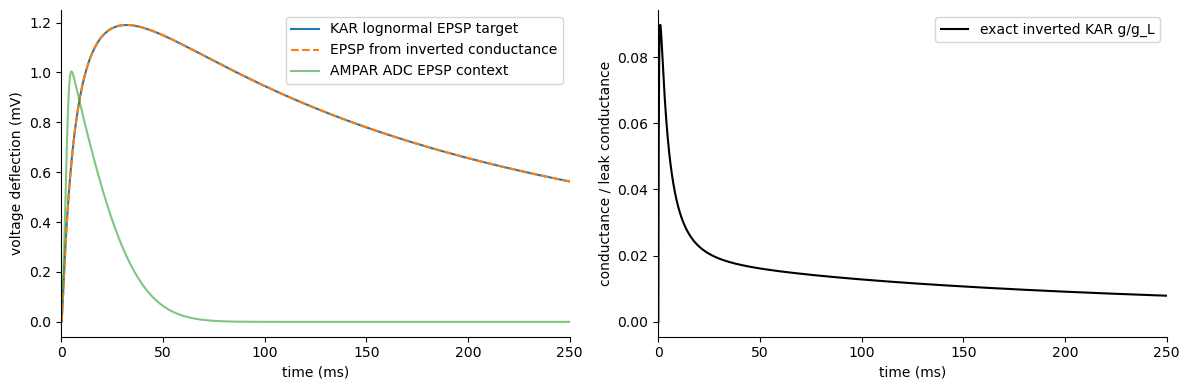

In [4]:

dt_ms = 0.1
t_stop_ms = 500.0
t = np.arange(0.0, t_stop_ms + dt_ms, dt_ms)

kar_epsp_target = kar_lognormal_epsp(t, **FRERKING_KAR)
g_exact = kar_g_over_gl_exact(t, tau_m_ms=tau_m_ms, e_l_mv=e_l_mv, e_exc_mv=e_exc_mv, **FRERKING_KAR)
kar_epsp_reconstructed = passive_epsp_from_g_over_gl(t, g_exact, tau_m_ms=tau_m_ms, e_l_mv=e_l_mv, e_exc_mv=e_exc_mv)
ampa_epsp_context = ampa_adc_epsp(t, **FRERKING_AMPA)

exact_summary_df = pd.DataFrame([
    {"quantity": "exact inverted g/g_L peak", "value": g_exact.max(), "time_ms": t[np.argmax(g_exact)], "units": "g_L units"},
    {"quantity": "exact inverted g/g_L area", "value": trapz_area(t, g_exact), "time_ms": np.nan, "units": "g_L*ms"},
    {"quantity": "target KAR EPSP peak", "value": kar_epsp_target.max(), "time_ms": t[np.argmax(kar_epsp_target)], "units": "mV"},
    {"quantity": "forwarded EPSP peak", "value": kar_epsp_reconstructed.max(), "time_ms": t[np.argmax(kar_epsp_reconstructed)], "units": "mV"},
    {"quantity": "forward reconstruction RMSE", "value": np.sqrt(np.mean((kar_epsp_reconstructed - kar_epsp_target) ** 2)), "time_ms": np.nan, "units": "mV"},
])
display(tidy_display(exact_summary_df, "Exact conductance inversion check"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, kar_epsp_target, label="KAR lognormal EPSP target")
axes[0].plot(t, kar_epsp_reconstructed, "--", label="EPSP from inverted conductance")
axes[0].plot(t, ampa_epsp_context, alpha=0.6, label="AMPAR ADC EPSP context")
axes[0].set_xlim(0, 250)
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("voltage deflection (mV)")
axes[0].legend()

axes[1].plot(t, g_exact, color="black", label="exact inverted KAR g/g_L")
axes[1].set_xlim(0, 250)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("conductance / leak conductance")
axes[1].legend()
plt.tight_layout()



## Paper-style EPSC waveform

The paper says they transformed model EPSP waveforms into simulated EPSC waveforms through a passive membrane model, then convolved those EPSCs over afferent spike patterns for current injection.

For a passive current-injection model:

```text
tau_m * du/dt = -u + I_syn / g_L
I_syn / g_L = tau_m * du/dt + u
```

This is slightly different from the conductance inversion used for the network model:

```text
g_syn / g_L = (tau_m * du/dt + u) / (E_exc - E_L - u)
```

Because the KAR EPSP is small relative to the excitatory driving force, the current waveform and conductance waveform have nearly the same shape, but the current form is the more literal version of the paper's simulated EPSC model.


,quantity,value,units
0,KAR inverse EPSC/g_L peak,5.81671,mV-equivalent
1,KAR inverse EPSC/g_L area,327.50451,mV*ms
2,paper-style current forward RMSE,0.00064,mV


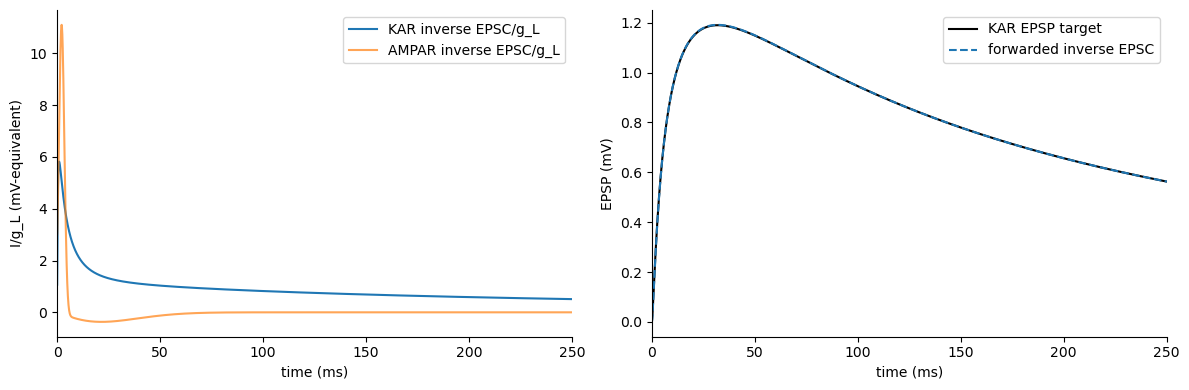

In [5]:

def current_over_gl_mv_from_epsp(t_ms, epsp_mv, tau_m_ms):
    """Passive inverse current: I_syn / g_L in mV-equivalent units."""
    du_dt = np.gradient(epsp_mv, t_ms)
    return tau_m_ms * du_dt + epsp_mv


def passive_epsp_from_current_over_gl_mv(t_ms, current_over_gl_mv, tau_m_ms):
    """Forward passive response to current injection, returning voltage deflection in mV."""
    t = np.asarray(t_ms, dtype=float)
    current = np.asarray(current_over_gl_mv, dtype=float)
    u = np.zeros_like(t)
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        du_dt = (-u[i - 1] + current[i - 1]) / tau_m_ms
        u[i] = u[i - 1] + dt * du_dt
    return u

kar_epsc_over_gl_mv = current_over_gl_mv_from_epsp(t, kar_epsp_target, tau_m_ms)
ampa_epsc_over_gl_mv = current_over_gl_mv_from_epsp(t, ampa_epsp_context, tau_m_ms)
kar_epsp_from_paper_epsc = passive_epsp_from_current_over_gl_mv(t, kar_epsc_over_gl_mv, tau_m_ms)

paper_epsc_summary_df = pd.DataFrame([
    {"quantity": "KAR inverse EPSC/g_L peak", "value": kar_epsc_over_gl_mv.max(), "units": "mV-equivalent"},
    {"quantity": "KAR inverse EPSC/g_L area", "value": trapz_area(t, kar_epsc_over_gl_mv), "units": "mV*ms"},
    {"quantity": "paper-style current forward RMSE", "value": np.sqrt(np.mean((kar_epsp_from_paper_epsc - kar_epsp_target) ** 2)), "units": "mV"},
])
display(tidy_display(paper_epsc_summary_df, "Paper-style passive EPSC inversion"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, kar_epsc_over_gl_mv, label="KAR inverse EPSC/g_L")
axes[0].plot(t, ampa_epsc_over_gl_mv, label="AMPAR inverse EPSC/g_L", alpha=0.7)
axes[0].set_xlim(0, 250)
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("I/g_L (mV-equivalent)")
axes[0].legend()

axes[1].plot(t, kar_epsp_target, color="black", label="KAR EPSP target")
axes[1].plot(t, kar_epsp_from_paper_epsc, "--", label="forwarded inverse EPSC")
axes[1].set_xlim(0, 250)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("EPSP (mV)")
axes[1].legend()
plt.tight_layout()



## Fit only sum-of-decays candidates

Candidate form:

```text
g_fit(t) = A1 * exp(-t/tau1) + ... + An * exp(-t/taun), t > 0
```

This maps directly to NEURON as one state variable per decay component:

```text
D1' = -D1/tau1
...
g = gmax * block * (D1 + ... + Dn)
```

Each presynaptic event increments the states by `weight * Ai`. No event history or LUT summation is needed.


In [6]:

def decay_unit(t_ms, tau_ms):
    y = np.zeros_like(t_ms, dtype=float)
    if tau_ms <= 0.0:
        return y
    mask = t_ms > 0.0
    y[mask] = np.exp(-t_ms[mask] / tau_ms)
    return y


def weighted_nnls(basis_columns, target, weights):
    basis = np.column_stack(basis_columns)
    coef, _ = nnls(basis * weights[:, None], target * weights)
    return coef, basis @ coef


def fit_sum_decay(n_components, starts=None, tau_bounds=(0.05, 800.0)):
    target = g_exact
    weights = fit_weights

    if starts is None:
        starts = [tuple(np.geomspace(0.5, 250.0, n_components))]
        starts.append(tuple(np.geomspace(2.0, 500.0, n_components)))
        starts.append(tuple(np.geomspace(5.0, 700.0, n_components)))

    def residual(log_taus):
        taus = np.sort(np.exp(log_taus))
        basis = [decay_unit(t, tau) for tau in taus]
        _, pred = weighted_nnls(basis, target, weights)
        return (pred - target) * weights

    lower = np.log(np.full(n_components, tau_bounds[0]))
    upper = np.log(np.full(n_components, tau_bounds[1]))
    best = None
    for start in starts:
        res = least_squares(
            residual,
            x0=np.log(start),
            bounds=(lower, upper),
            max_nfev=1000,
        )
        if best is None or res.cost < best.cost:
            best = res

    taus = np.sort(np.exp(best.x))
    basis = [decay_unit(t, tau) for tau in taus]
    amps, g_fit = weighted_nnls(basis, target, weights)
    epsp_fit = passive_epsp_from_g_over_gl(t, g_fit, tau_m_ms=tau_m_ms, e_l_mv=e_l_mv, e_exc_mv=e_exc_mv)
    return {
        "name": f"sum_decay_{n_components}",
        "n_components": n_components,
        "taus_ms": np.asarray(taus),
        "amps": np.asarray(amps),
        "g": g_fit,
        "epsp": epsp_fit,
        "cost": float(best.cost),
    }


def half_width_ms(t_ms, y):
    peak = y.max()
    if peak <= 0.0:
        return np.nan
    idx = np.flatnonzero(y >= 0.5 * peak)
    return float(t_ms[idx[-1]] - t_ms[idx[0]]) if len(idx) else np.nan


def value_at(t_ms, y, query_ms):
    return float(np.interp(query_ms, t_ms, y))


def fit_metrics(fit):
    g = fit["g"]
    epsp = fit["epsp"]
    err = g - g_exact
    weighted_err = err * fit_weights
    sse = float(np.sum(weighted_err ** 2))
    n_obs = int(np.count_nonzero(fit_weights))
    k = 2 * fit["n_components"]
    bic_like = n_obs * np.log(max(sse / max(n_obs, 1), 1e-30)) + k * np.log(max(n_obs, 1))
    return {
        "name": fit["name"],
        "n_components": fit["n_components"],
        "g_rmse": float(np.sqrt(np.mean(err ** 2))),
        "g_weighted_rmse": float(np.sqrt(np.mean(weighted_err[fit_weights > 0] ** 2))),
        "g_area": trapz_area(t, g),
        "g_peak": float(g.max()),
        "g_peak_t_ms": float(t[np.argmax(g)]),
        "epsp_rmse_validation": float(np.sqrt(np.mean((epsp - kar_epsp_target) ** 2))),
        "epsp_peak_mV": float(epsp.max()),
        "epsp_peak_t_ms": float(t[np.argmax(epsp)]),
        "epsp_half_width_ms": half_width_ms(t, epsp),
        "epsp_tail_100_mV": value_at(t, epsp, 100.0),
        "epsp_tail_200_mV": value_at(t, epsp, 200.0),
        "bic_like": bic_like,
    }


In [7]:

fit_t_min_ms = 0.1
fit_t_max_ms = 300.0
fit_weights = np.zeros_like(t)
fit_weights[(t >= fit_t_min_ms) & (t <= fit_t_max_ms)] = 1.0
fit_weights[(t > 100.0) & (t <= fit_t_max_ms)] = 0.7

MAX_DECAY_COMPONENTS = 4
fits = [fit_sum_decay(n) for n in range(2, MAX_DECAY_COMPONENTS + 1)]
metrics_df = pd.DataFrame([fit_metrics(fit) for fit in fits]).sort_values("bic_like").reset_index(drop=True)
display(tidy_display(metrics_df, "Conductance-objective sum-of-decays fits"))

best_name = metrics_df.iloc[0]["name"]
best_fit = next(fit for fit in fits if fit["name"] == best_name)
fit_param_rows = []
for fit in fits:
    row = {"name": fit["name"], "n_components": fit["n_components"]}
    for i, (tau_i, amp_i) in enumerate(zip(fit["taus_ms"], fit["amps"]), start=1):
        row[f"tau{i}_ms"] = tau_i
        row[f"amp{i}"] = amp_i
    fit_param_rows.append(row)
fit_params_df = pd.DataFrame(fit_param_rows)
display(tidy_display(fit_params_df, "Fitted decay parameters"))
display(Markdown(f"**Selected candidate:** `{best_fit['name']}` by BIC-like conductance score."))


,name,n_components,g_rmse,g_weighted_rmse,g_area,g_peak,g_peak_t_ms,epsp_rmse_validation,epsp_peak_mV,epsp_peak_t_ms,epsp_half_width_ms,epsp_tail_100_mV,epsp_tail_200_mV,bic_like
0,sum_decay_3,3,0.00111,0.00143,5.09311,0.08969,0.10000,0.00280,1.18844,30.40000,226.30000,0.94810,0.65448,-39242.43972
1,sum_decay_4,4,0.00111,0.00143,5.09315,0.08969,0.10000,0.00280,1.18844,30.40000,226.30000,0.94810,0.65448,-39226.42698
2,sum_decay_2,2,0.00135,0.00146,4.87149,0.08892,0.10000,0.04188,1.18128,28.80000,229.20000,0.95702,0.66805,-39155.40126


,name,n_components,tau1_ms,amp1,tau2_ms,amp2,tau3_ms,amp3,tau4_ms,amp4
0,sum_decay_2,2,7.17214,0.07076,271.09295,0.01914,,,,
1,sum_decay_3,3,6.72873,0.06942,81.75126,0.00850,468.73377,0.01281,,
2,sum_decay_4,4,0.50000,0.00000,6.72876,0.06942,81.77303,0.00851,468.85564,0.01280


**Selected candidate:** `sum_decay_3` by BIC-like conductance score.


## Visual validation

These plots do not refit anything. They check whether conductance-fitted candidates also regenerate a reasonable passive EPSP.


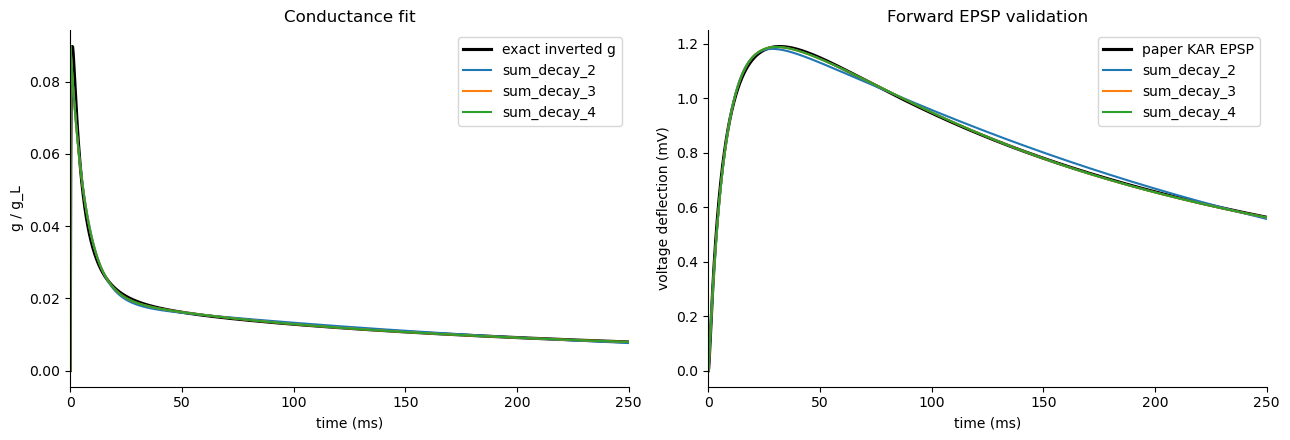

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(t, g_exact, color="black", lw=2.25, label="exact inverted g")
for fit in fits:
    axes[0].plot(t, fit["g"], label=fit["name"])
axes[0].set_xlim(0, 250)
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("g / g_L")
axes[0].set_title("Conductance fit")
axes[0].legend()

axes[1].plot(t, kar_epsp_target, color="black", lw=2.25, label="paper KAR EPSP")
for fit in fits:
    axes[1].plot(t, fit["epsp"], label=fit["name"])
axes[1].set_xlim(0, 250)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("voltage deflection (mV)")
axes[1].set_title("Forward EPSP validation")
axes[1].legend()
plt.tight_layout()



## Paper-style event train validation

This uses the paper's reported short-term plasticity values only as a validation stress test:

```text
U_init = 0.18
tau_facil = 210 ms
tau_rec = 1095 ms
```


,events,mean_stp_weight,max_stp_weight
0,233,0.17748,0.32760


,name,peak_mV,median_mV,cv,rmse_vs_exact_mV
0,exact_reference,8.43967,5.97610,0.23960,0.00000
1,sum_decay_2,8.17128,5.73314,0.23842,0.23574
2,sum_decay_3,8.43384,5.97627,0.23965,0.00483
3,sum_decay_4,8.43389,5.97632,0.23965,0.00480


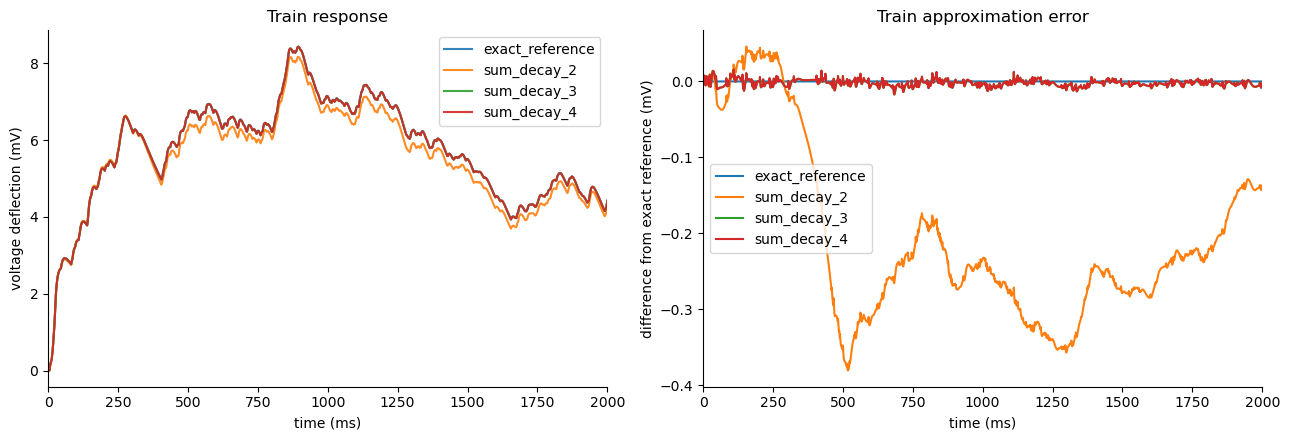

In [9]:

def make_poisson_afferent_events(n_afferents=25, rate_hz=5.0, t_stop_ms=2000.0, seed=1):
    rng = np.random.default_rng(seed)
    all_times = []
    all_ids = []
    for aff in range(n_afferents):
        t_now = 0.0
        while t_now < t_stop_ms:
            t_now += rng.exponential(1000.0 / rate_hz)
            if t_now < t_stop_ms:
                all_times.append(t_now)
                all_ids.append(aff)
    order = np.argsort(all_times)
    return np.asarray(all_times)[order], np.asarray(all_ids)[order]


def make_theta_afferent_events(n_afferents=25, theta_hz=8.0, jitter_ms=12.0, cycles=16, seed=2):
    rng = np.random.default_rng(seed)
    period_ms = 1000.0 / theta_hz
    all_times = []
    all_ids = []
    for cycle in range(cycles):
        center = cycle * period_ms
        for aff in range(n_afferents):
            if rng.random() < 0.65:
                all_times.append(max(0.0, center + rng.normal(0.0, jitter_ms)))
                all_ids.append(aff)
    order = np.argsort(all_times)
    return np.asarray(all_times)[order], np.asarray(all_ids)[order]


def stp_event_weights(event_times_ms, afferent_ids, n_afferents, U_init=0.18, tau_facil_ms=210.0, tau_rec_ms=1095.0):
    u = np.full(n_afferents, U_init, dtype=float)
    R = np.ones(n_afferents, dtype=float)
    last = np.full(n_afferents, np.nan, dtype=float)
    weights = np.zeros_like(event_times_ms, dtype=float)
    for k, (event_t, aff) in enumerate(zip(event_times_ms, afferent_ids)):
        if not np.isnan(last[aff]):
            dt_event = event_t - last[aff]
            u[aff] = U_init + (u[aff] - U_init) * np.exp(-dt_event / tau_facil_ms)
            R[aff] = 1.0 - (1.0 - R[aff]) * np.exp(-dt_event / tau_rec_ms)
        u[aff] = u[aff] + U_init * (1.0 - u[aff])
        weights[k] = u[aff] * R[aff]
        R[aff] = R[aff] * (1.0 - u[aff])
        last[aff] = event_t
    return weights


def synthesize_from_events(t_ms, event_times_ms, event_weights, kernel):
    dt = t_ms[1] - t_ms[0]
    y = np.zeros_like(t_ms, dtype=float)
    for event_t, weight in zip(event_times_ms, event_weights):
        start = int(round(event_t / dt))
        if start >= len(t_ms):
            continue
        count = min(len(kernel), len(t_ms) - start)
        y[start:start + count] += weight * kernel[:count]
    return y

train_t_stop_ms = 2000.0
event_times, aff_ids = make_poisson_afferent_events(n_afferents=25, rate_hz=5.0, t_stop_ms=train_t_stop_ms, seed=4)
# event_times, aff_ids = make_theta_afferent_events(n_afferents=25, theta_hz=8.0, jitter_ms=12.0, cycles=16, seed=4)
event_weights = stp_event_weights(event_times, aff_ids, n_afferents=25, **PAPER_STP)
train_t = np.arange(0.0, train_t_stop_ms + dt_ms, dt_ms)

train_exact_g = synthesize_from_events(train_t, event_times, event_weights, g_exact)
train_exact_v = passive_epsp_from_g_over_gl(train_t, train_exact_g, tau_m_ms=tau_m_ms, e_l_mv=e_l_mv, e_exc_mv=e_exc_mv)
train_results = {"exact_reference": (train_exact_g, train_exact_v)}
for fit in fits:
    train_g = synthesize_from_events(train_t, event_times, event_weights, fit["g"])
    train_v = passive_epsp_from_g_over_gl(train_t, train_g, tau_m_ms=tau_m_ms, e_l_mv=e_l_mv, e_exc_mv=e_exc_mv)
    train_results[fit["name"]] = (train_g, train_v)

event_summary_df = pd.DataFrame([{
    "events": len(event_times),
    "mean_stp_weight": event_weights.mean(),
    "max_stp_weight": event_weights.max(),
}])
display(tidy_display(event_summary_df, "Event train summary"))

train_metric_rows = []
for name, (_, train_v) in train_results.items():
    train_metric_rows.append({
        "name": name,
        "peak_mV": train_v.max(),
        "median_mV": np.percentile(train_v, 50),
        "cv": np.std(train_v) / max(np.mean(train_v), 1e-12),
        "rmse_vs_exact_mV": np.sqrt(np.mean((train_v - train_exact_v) ** 2)),
    })
train_metrics_df = pd.DataFrame(train_metric_rows)
display(tidy_display(train_metrics_df, "Train response metrics"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, (_, train_v) in train_results.items():
    axes[0].plot(train_t, train_v, label=name, alpha=0.9)
axes[0].set_xlim(0, train_t_stop_ms)
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("voltage deflection (mV)")
axes[0].set_title("Train response")
axes[0].legend()

for name, (_, train_v) in train_results.items():
    axes[1].plot(train_t, train_v - train_exact_v, label=name)
axes[1].set_xlim(0, train_t_stop_ms)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("difference from exact reference (mV)")
axes[1].set_title("Train approximation error")
axes[1].legend()
plt.tight_layout()



## Export selected candidate to `KainateSyn.mod`

This cell is guarded by `APPLY_TO_MODEL`. When enabled, it writes the selected sum-of-decays candidate into `prev_ob_models/Birgiolas2020/Mechanisms/KainateSyn.mod`, updates the base `kar_tau1`, `kar_tau2`, and `kar_kd` defaults that the Python model applies at runtime, and recompiles mechanisms in the `OBGPU` environment.

`kar_kd` is set to `0.0` because saturation distorts the calibrated single-event kernel. Re-enable positive `kar_kd` only for a separate saturation sensitivity test.


In [10]:
import os
import platform
import re
import subprocess

APPLY_TO_MODEL = True
RECOMPILE_AFTER_WRITE = True
CORENEURON_COMPILE = True
REPAIR_NVHPC_FATBIN = True


def mod_float(x):
    return f"{float(x):.10g}"


def make_sum_decay_kainate_mod(fit):
    n = int(fit["n_components"])
    taus = [float(x) for x in fit["taus_ms"]]
    amps = [float(x) for x in fit["amps"]]
    ranges = [f"tau{i}" for i in range(1, n + 1)] + [f"amp{i}" for i in range(1, n + 1)]
    states = [f"D{i}" for i in range(1, n + 1)]
    parameter_lines = []
    for i, tau_i in enumerate(taus, start=1):
        parameter_lines.append(f"    tau{i} = {mod_float(tau_i)} (ms) <1e-9,1e9>")
    for i, amp_i in enumerate(amps, start=1):
        parameter_lines.append(f"    amp{i} = {mod_float(amp_i)} (1)")
    derivative_lines = [f"    D{i}' = -D{i}/tau{i}" for i in range(1, n + 1)]
    receive_lines = [f"    D{i} = D{i} + weight*amp{i}" for i in range(1, n + 1)]
    state_zero_lines = [f"    D{i} = 0" for i in range(1, n + 1)]
    x_sum = " + ".join(states)
    return f'''TITLE fitted sum-of-decays kainate receptor synapse

COMMENT
Event-driven glutamate-gated kainate receptor current.

This file was generated from notebooks/kar_kernel_approximation.ipynb.
The kernel is a conductance-objective fit to the Frerking and Ohliger-Frerking
KAR EPSP after passive analytical inversion:

    g_K(t) / g_L ~= sum_i amp_i * exp(-t / tau_i)

Use kd = 0 for the calibrated linear single-event kernel. Positive kd applies
a saturation nonlinearity for sensitivity tests.
ENDCOMMENT

NEURON {{
    POINT_PROCESS KainateSyn
    RANGE {", ".join(ranges)}, e, i, g, x, gmax, kd, block
    NONSPECIFIC_CURRENT i
}}

UNITS {{
    (nA) = (nanoamp)
    (mV) = (millivolt)
    (uS) = (microsiemens)
}}

PARAMETER {{
{chr(10).join(parameter_lines)}
    gmax = 0 (uS)
    kd = 0 (1)
    block = 1 (1)
    e = 0 (mV)
}}

ASSIGNED {{
    v (mV)
    i (nA)
    g (uS)
    x (1)
}}

STATE {{
    {" ".join(states)}
}}

INITIAL {{
{chr(10).join(state_zero_lines)}
}}

BREAKPOINT {{
    SOLVE state METHOD cnexp
    x = {x_sum}
    if (x < 0) {{
        x = 0
    }}
    if (kd > 0) {{
        g = gmax * block * x / (kd + x)
    }} else {{
        g = gmax * block * x
    }}
    i = g * (v - e)
}}

DERIVATIVE state {{
{chr(10).join(derivative_lines)}
}}

NET_RECEIVE(weight) {{
{chr(10).join(receive_lines)}
}}
'''


def patch_base_defaults(base_path, fit):
    text = base_path.read_text()
    replacements = {"kar_kd": 0.0}
    for i, tau_i in enumerate(fit["taus_ms"], start=1):
        replacements[f"kar_tau{i}"] = float(tau_i)
    for i, amp_i in enumerate(fit["amps"], start=1):
        replacements[f"kar_amp{i}"] = float(amp_i)

    for key, value in replacements.items():
        pattern = rf"(^\s*{key}\s*=\s*)[^\n]+"
        text, count = re.subn(pattern, rf"\g<1>{mod_float(value)}", text, flags=re.MULTILINE)
        if count != 1:
            raise RuntimeError(f"Expected exactly one assignment for {key}, found {count}")
    base_path.write_text(text)


def run_and_display(cmd, *, cwd, env=None, label):
    result = subprocess.run(cmd, cwd=cwd, env=env, text=True, capture_output=True)
    result_df = pd.DataFrame([{
        "step": label,
        "command": " ".join(str(part) for part in cmd),
        "returncode": result.returncode,
        "stdout_lines": len(result.stdout.splitlines()),
        "stderr_lines": len(result.stderr.splitlines()),
    }])
    display(tidy_display(result_df, f"{label} result"))
    if result.stdout.strip():
        display(Markdown("```text\n" + "\n".join(result.stdout.splitlines()[-40:]) + "\n```"))
    if result.stderr.strip():
        display(Markdown("```text\n" + "\n".join(result.stderr.splitlines()[-40:]) + "\n```"))
    if result.returncode != 0:
        raise RuntimeError(f"{label} failed")
    return result


selected_fit = best_fit
mod_text = make_sum_decay_kainate_mod(selected_fit)
mod_path = REPO / "prev_ob_models" / "Birgiolas2020" / "Mechanisms" / "KainateSyn.mod"
base_path = REPO / "olfactorybulb" / "paramsets" / "base.py"

export_summary_df = pd.DataFrame([{
    "selected": selected_fit["name"],
    "n_components": selected_fit["n_components"],
    "mod_path": str(mod_path.relative_to(REPO)),
    "base_path": str(base_path.relative_to(REPO)),
    "apply_to_model": APPLY_TO_MODEL,
    "recompile_after_write": RECOMPILE_AFTER_WRITE,
    "coreneuron_compile": CORENEURON_COMPILE,
    "repair_nvhpc_fatbin": REPAIR_NVHPC_FATBIN,
}])
display(tidy_display(export_summary_df, "Export target"))

if APPLY_TO_MODEL:
    mod_path.write_text(mod_text)
    patch_base_defaults(base_path, selected_fit)
    display(Markdown(f"Wrote `{mod_path.relative_to(REPO)}` and patched `{base_path.relative_to(REPO)}`."))
    if RECOMPILE_AFTER_WRITE:
        cmd = ["/opt/miniconda3/envs/OBGPU/bin/nrnivmodl"]
        if CORENEURON_COMPILE:
            cmd.append("-coreneuron")
        cmd.append(str(mod_path.parent.relative_to(REPO)))
        compile_env = os.environ.copy()
        compile_env.setdefault("OMPI_CC", "gcc")
        compile_env.setdefault("OMPI_CXX", "g++")
        run_and_display(cmd, cwd=REPO, env=compile_env, label="nrnivmodl")

        if CORENEURON_COMPILE and REPAIR_NVHPC_FATBIN:
            repair_script = REPO / "tools" / "setup" / "fix_nvhpc_libnrnmech.sh"
            libnrnmech = REPO / platform.machine() / "libnrnmech.so"
            if not repair_script.exists():
                raise RuntimeError(f"Repair script not found: {repair_script}")
            if not libnrnmech.exists():
                raise RuntimeError(f"Compiled mechanism library not found: {libnrnmech}")
            run_and_display([str(repair_script), str(libnrnmech)], cwd=REPO, label="NVHPC fatbin repair")
else:
    display(Markdown(
        "Set `APPLY_TO_MODEL = True` in this cell and rerun it to write the selected candidate "
        "and recompile mechanisms. Preview of generated MOD file:"
    ))
    display(Markdown("```mod\n" + mod_text[:5000] + "\n```"))


,selected,n_components,mod_path,base_path,apply_to_model,recompile_after_write,coreneuron_compile,repair_nvhpc_fatbin
0,sum_decay_3,3,prev_ob_models/Birgiolas2020/Mechanisms/KainateSyn.mod,olfactorybulb/paramsets/base.py,True,True,True,True


Wrote `prev_ob_models/Birgiolas2020/Mechanisms/KainateSyn.mod` and patched `olfactorybulb/paramsets/base.py`.

,step,command,returncode,stdout_lines,stderr_lines
0,nrnivmodl,/opt/miniconda3/envs/OBGPU/bin/nrnivmodl -coreneuron prev_ob_models/Birgiolas2020/Mechanisms,0,15,4


```text
/home/alek/OlfactoryBulb
cfiles =
Mod files: "prev_ob_models/Birgiolas2020/Mechanisms/AmpaNmdaSyn.mod" "prev_ob_models/Birgiolas2020/Mechanisms/CaPool.mod" "prev_ob_models/Birgiolas2020/Mechanisms/CaT.mod" "prev_ob_models/Birgiolas2020/Mechanisms/GabaSyn.mod" "prev_ob_models/Birgiolas2020/Mechanisms/Ih.mod" "prev_ob_models/Birgiolas2020/Mechanisms/KA.mod" "prev_ob_models/Birgiolas2020/Mechanisms/KCa.mod" "prev_ob_models/Birgiolas2020/Mechanisms/KM.mod" "prev_ob_models/Birgiolas2020/Mechanisms/KainateSyn.mod" "prev_ob_models/Birgiolas2020/Mechanisms/Kd.mod" "prev_ob_models/Birgiolas2020/Mechanisms/Kslow.mod" "prev_ob_models/Birgiolas2020/Mechanisms/LCa.mod" "prev_ob_models/Birgiolas2020/Mechanisms/Na.mod" "prev_ob_models/Birgiolas2020/Mechanisms/VecStim.mod" "prev_ob_models/Birgiolas2020/Mechanisms/gapjunction.mod"

MODOBJS= ./AmpaNmdaSyn.o ./CaPool.o ./CaT.o ./GabaSyn.o ./Ih.o ./KA.o ./KCa.o ./KM.o ./KainateSyn.o ./Kd.o ./Kslow.o ./LCa.o ./Na.o ./VecStim.o ./gapjunction.o
[INFO] Running: make -j4 -f /opt/miniconda3/envs/OBGPU/share/coreneuron/nrnivmodl_core_makefile ROOT=/opt/miniconda3/envs/OBGPU MODS_PATH=aarch64/corenrn/mod2c BUILD_TYPE=SHARED NRN_PRCELLSTATE=0
Default NMODL flags: 
 => [32mBinary[0m creating aarch64/special-core
[INFO] MOD files built successfully for CoreNEURON
 -> [32mNMODL[0m ../prev_ob_models/Birgiolas2020/Mechanisms/KainateSyn.mod
 -> [32mCompiling[0m mod_func.cpp
 -> [32mCompiling[0m /home/alek/OlfactoryBulb/aarch64/KainateSyn.cpp
 => [32mLINKING[0m shared library "/home/alek/OlfactoryBulb/aarch64/./libnrnmech.so"
 => [32mLINKING[0m executable "/home/alek/OlfactoryBulb/aarch64/./special" LDFLAGS are:     
Successfully created aarch64/special
```

```text
/opt/miniconda3/envs/OBGPU/share/coreneuron/coreneuron.cpp:
Translating KainateSyn.mod into /home/alek/OlfactoryBulb/aarch64/KainateSyn.cpp
Thread Safe
/opt/miniconda3/envs/OBGPU/share/nrn/nrnmain.cpp:
```

,step,command,returncode,stdout_lines,stderr_lines
0,NVHPC fatbin repair,/home/alek/OlfactoryBulb/tools/setup/fix_nvhpc_libnrnmech.sh /home/alek/OlfactoryBulb/aarch64/libnrnmech.so,0,0,0



## Why not an exact LUT at network scale?

A lookup-table exact kernel must remember every active event until the kernel tail cutoff and sum the table value for each event every time step. That makes work and memory scale with:

```text
number_of_synapses * firing_rate * tail_cutoff
```

The sum-of-decays form stores only one state variable per decay component, independent of the number of previous events. Events increment the states; `cnexp` handles the decays. That is the fixed-state implementation pattern NEURON/CoreNEURON handles well.
